In [119]:
import cv2
import numpy as np
import os

with open("images/images.txt", mode="w") as f:
    f.write("image, underwater\n")

for file in sorted(os.listdir("./images")):
    with open("images/images.txt", mode="a") as f:
        f.write(f"{file}, \n")

Underwater image example: 100006681.jpg


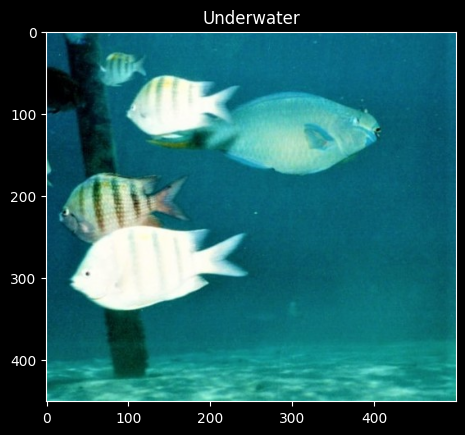

Above water image example: 100003973.jpg


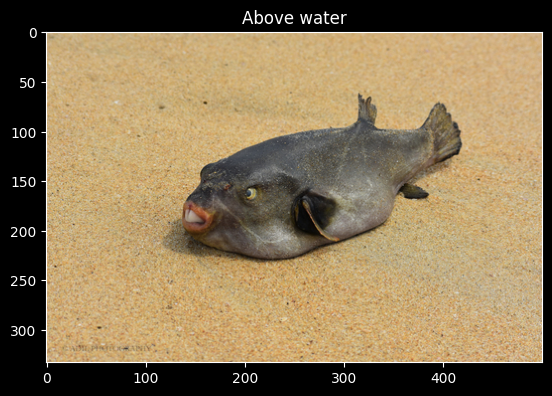

In [120]:
import csv
import matplotlib.pyplot as plt

with open("images/images_labelled.txt", mode="r") as f:
    reader = csv.DictReader(f, delimiter=',')
    data = [row for row in reader]

underwater = [img.get("image") for img in data if img.get(" underwater") == " 1"]
abovewater = [img.get("image") for img in data if img.get("image") not in underwater]

print(f"Underwater image example: {underwater[0]}")
img_bgr = cv2.imread(f'images/{underwater[0]}')
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title('Underwater')
plt.show()

print(f"Above water image example: {abovewater[0]}")
img_bgr = cv2.imread(f'images/{abovewater[0]}')
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title('Above water')
plt.show()

In [121]:
red_means_underwater = []
blue_means_underwater = []

for img in underwater:
    img_bgr = cv2.imread(f'images/{img}')
    img_bgr = img_bgr.astype(np.float64)
    r_mean = img_bgr[..., 2].mean()
    b_mean = img_bgr[..., 0].mean()
    g_mean = img_bgr[..., 1].mean()

    total = r_mean + b_mean + g_mean

    red_means_underwater.append(r_mean / total)
    blue_means_underwater.append(b_mean / total)

red_avg_score = np.mean(red_means_underwater)
blue_avg_score = np.mean(blue_means_underwater)
print(f"Red avg score: {red_avg_score}")
print(f"Blue avg score: {blue_avg_score}")


Red avg score: 0.27615152905894635
Blue avg score: 0.3327996806786146


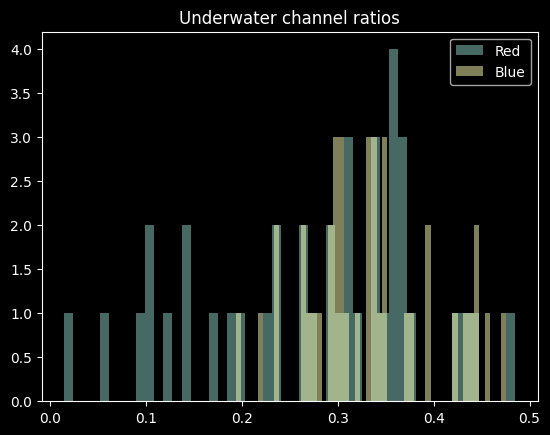

In [122]:
plt.hist(red_means_underwater, bins=50, alpha=0.5, label='Red')
plt.hist(blue_means_underwater, bins=50, alpha=0.5, label='Blue')
plt.legend()
plt.title('Underwater channel ratios')
plt.show()

In [123]:
red_means_abovewater = []
blue_means_abovewater = []

for img in abovewater:
    img_bgr = cv2.imread(f'images/{img}')
    img_bgr = img_bgr.astype(np.float64)
    r_mean = img_bgr[..., 2].mean()
    b_mean = img_bgr[..., 0].mean()
    g_mean = img_bgr[..., 1].mean()

    total = r_mean + b_mean + g_mean

    red_means_abovewater.append(r_mean / total)
    blue_means_abovewater.append(b_mean / total)

red_avg_score = np.mean(red_means_abovewater)
blue_avg_score = np.mean(blue_means_abovewater)
print(f"Red avg score: {red_avg_score}")
print(f"Blue avg score: {blue_avg_score}")


Red avg score: 0.3602637650151051
Blue avg score: 0.30537881121970406


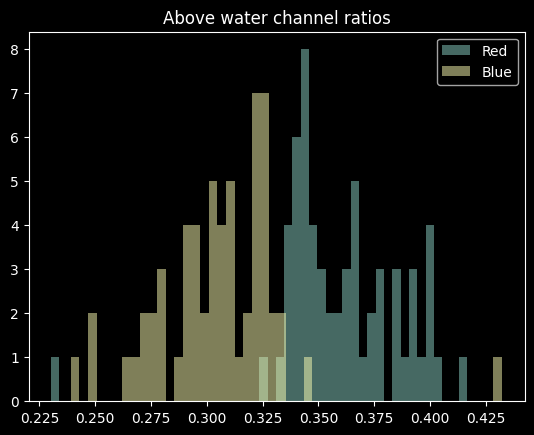

In [124]:
plt.hist(red_means_abovewater, bins=50, alpha=0.5, label='Red')
plt.hist(blue_means_abovewater, bins=50, alpha=0.5, label='Blue')
plt.legend()
plt.title('Above water channel ratios')
plt.show()

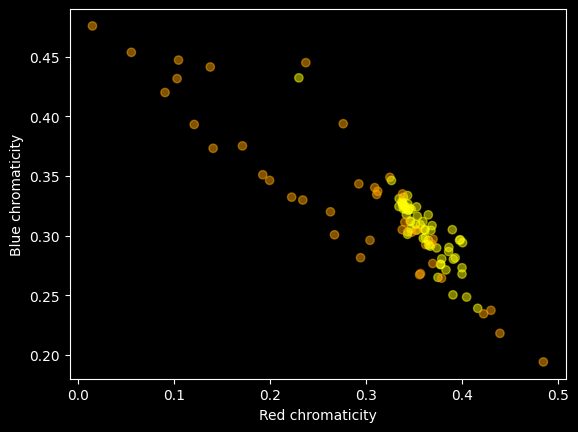

Image 100006681.jpg, label: 1
Image 100011202.jpg, label: 1
Image 10001516.jpeg, label: 1
Image 10001596.jpeg, label: 1
Image 10001598.jpeg, label: 1
Image 10001602.jpeg, label: 1
Image 10001603.jpeg, label: 1
Image 10001604.jpeg, label: 1
Image 10001605.jpeg, label: 1
Image 10001609.jpeg, label: 1
Image 10001618.jpeg, label: 1
Image 10001639.jpeg, label: 1
Image 10001641.jpeg, label: 1
Image 100018788.jpg, label: 1
Image 100019022.jpg, label: 1
Image 100019024.jpg, label: 1
Image 100019025.jpg, label: 1
Image 100019026.jpg, label: 1
Image 100026491.jpg, label: 1
Image 100027928.jpg, label: 1
Image 100028290.jpg, label: 1
Image 100028291.jpg, label: 1
Image 100029157.jpeg, label: 1
Image 100029193.jpg, label: 1
Total underwater images: 40
Total caught images: 24
Total incorrect images: 2


In [152]:
all_images = [img.get('image') for img in data]
red_chrom = []
blue_chrom = []
green_chrom = []
std_chrom = []
labels = [int(img.get(" underwater").strip()) for img in data]
color = ['yellow' if label == 0 else 'orange' for label in labels]


for img in all_images:
    img_bgr = cv2.imread(f'images/{img}')
    img_bgr = img_bgr.astype(np.float64)
    r_mean = img_bgr[..., 2].mean()
    b_mean = img_bgr[..., 0].mean()
    g_mean = img_bgr[..., 1].mean()
    total = b_mean + r_mean + g_mean

    blue_chrom.append(b_mean / total)
    red_chrom.append(r_mean / total)
    green_chrom.append(g_mean / total)
    std_chrom.append(np.std([blue_chrom, red_chrom, green_chrom]))

plt.scatter(x=red_chrom, y=blue_chrom, c=color, alpha=0.5)
plt.xlabel('Red chromaticity')
plt.ylabel('Blue chromaticity')
plt.show()

count = 0
caught = 0
incorrect = 0
for img in list(zip(all_images, red_chrom, blue_chrom, labels)):
    count += img[3]
    if img[1] < 0.33:
        if img[3] == 1:
            print(f"Image {img[0]}, label: {img[3]}")
            caught += 1
        else:
            incorrect += 1

print(f'Total underwater images: {count}')
print(f'Total caught images: {caught}')
print(f'Total incorrect images: {incorrect}')

/tmp/ipykernel_21828/366900770.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


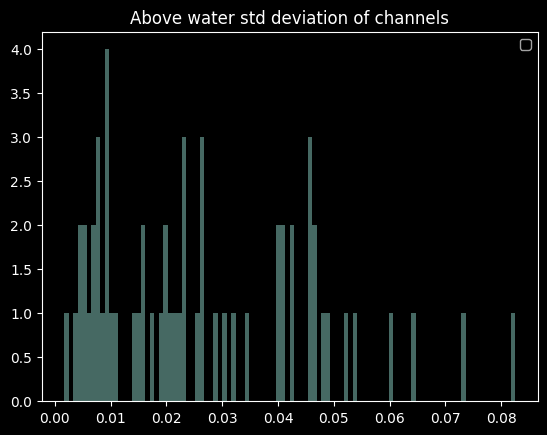

0.026617482027348354
['100003973.jpg', '100004417.jpg', '10000450.jpeg', '10000455.jpeg', '10000460.jpeg', '10000462.jpeg', '10000481.jpeg', '10000509.jpeg', '10000518.jpeg', '10000535.jpeg', '10000562.jpeg', '100005694.jpeg', '10000592.jpeg', '10000615.jpg', '10000659.jpeg', '10000676.jpeg', '100008156.jpg', '10000865.jpeg', '100010690.jpg', '100012606.jpg', '100019701.jpeg', '100019748.jpeg', '100019774.jpg', '100021308.jpg', '100021610.jpeg', '100021715.jpeg', '100021795.jpeg', '100021867.jpeg', '100022025.jpeg', '100022094.jpeg', '100024378.jpg', '100024395.jpg', '100025635.jpeg', '100025666.jpeg', '100025697.jpeg', '100025721.jpeg', '100025821.jpeg', '100025900.jpeg', '100025990.jpeg']


In [159]:
std_chrom = []

for img in abovewater:
    img_bgr = cv2.imread(f'images/{img}')
    img_bgr = img_bgr.astype(np.float64)
    r_mean = img_bgr[..., 2].mean()
    b_mean = img_bgr[..., 0].mean()
    g_mean = img_bgr[..., 1].mean()

    total = r_mean + b_mean + g_mean

    red_means = (r_mean / total)
    blue_means = (b_mean / total)
    green_means = (g_mean / total)

    std_chrom.append(np.std([red_means, blue_means, green_means]))

plt.hist(std_chrom, bins=100, alpha=0.5)
plt.legend()
plt.title('Above water std deviation of channels')
plt.show()


print(np.mean(std_chrom))
imgs_std = list(zip(abovewater, std_chrom))
print([img[0] for img in imgs_std if img[1] > 0.015])

/tmp/ipykernel_21828/3459079039.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


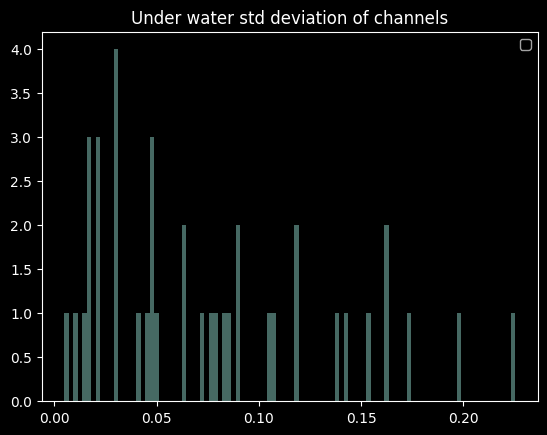

0.07645892907154334
['10001603.jpeg', '100021538.jpeg']


In [161]:
std_chrom = []

for img in underwater:
    img_bgr = cv2.imread(f'images/{img}')
    img_bgr = img_bgr.astype(np.float64)
    r_mean = img_bgr[..., 2].mean()
    b_mean = img_bgr[..., 0].mean()
    g_mean = img_bgr[..., 1].mean()

    total = r_mean + b_mean + g_mean

    red_means = (r_mean / total)
    blue_means = (b_mean / total)
    green_means = (g_mean / total)

    std_chrom.append(np.std([red_means, blue_means, green_means]))

plt.hist(std_chrom, bins=100, alpha=0.5)
plt.legend()
plt.title('Under water std deviation of channels')
plt.show()

print(np.mean(std_chrom))
imgs_std = list(zip(underwater, std_chrom))
print([img[0] for img in imgs_std if img[1] < 0.015])